In [34]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os
from shapely import wkt
import geopandas as gpd

In [35]:
# load all extracted dataframes
education = pd.read_csv("./output/education.csv")
income = pd.read_csv("./output/income.csv")
pops = pd.read_csv("./output/pops.csv")
racial = pd.read_csv("./output/racial.csv")

# merge all dataframes into one
df = pd.merge(education, income, on="ZIP Code")
df = pd.merge(df, pops, on="ZIP Code")
df = pd.merge(df, racial, on="ZIP Code")
# drop unnecessary columns
df.drop(columns=["geometry_old", "pop_est_old", 'geometry_y', 'geometry_x'], inplace=True)

# rename columns
columns_rename = {
    'S1501_C02_002E': 'less than highschool graduate',
    'S1501_C02_003E': 'high school graduate',
    'S1501_C02_004E':'some college or associate degree',
    'S1501_C02_005E':'bachelor\'s degree or higher',
    'S1901_C02_012E':'Median Household Income',
    'S1901_C02_013E':'Mean Household Income',
}

df.columns

Index(['ZIP Code', 'S1501_C02_002E', 'S1501_C02_003E', 'S1501_C02_004E',
       'S1501_C02_005E', 'S1901_C02_012E', 'S1901_C02_013E', 'SAFMR 1BR_old',
       'SAFMR 1BR_new', 'SAFMR_1BR_change', 'SAFMR_1BR_PERC_CHANGE',
       'pops_count', 'pop_est', 'geometry', 'SAFMR 1BR', 'change_perc_asian',
       'change_perc_black', 'change_perc_white', 'perc_white', 'perc_black',
       'perc_asian'],
      dtype='object')

In [36]:
# Convert the 'geometry' column from WKT text to real shapely objects
df['geometry'] = df['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
df = gpd.GeoDataFrame(df, geometry='geometry')

# (Optional but good practice) Set the CRS
df.set_crs(epsg=4326, inplace=True)  # WGS84 latitude/longitude

,ZIP Code,S1501_C02_002E,S1501_C02_003E,S1501_C02_004E,S1501_C02_005E,S1901_C02_012E,S1901_C02_013E,SAFMR 1BR_old,SAFMR 1BR_new,SAFMR_1BR_change,...,pops_count,pop_est,geometry,SAFMR 1BR,change_perc_asian,change_perc_black,change_perc_white,perc_white,perc_black,perc_asian
0,10001,1.2,37.0,28.4,33.5,182117.0,269616.0,2040.0,3220.0,1180.0,...,4.0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",3220.0,0.055519,0.022036,-0.076544,0.585334,0.124101,0.215285
1,10002,8.9,15.9,44.4,30.8,51093.0,98795.0,1410.0,2210.0,800.0,...,1.0,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",2210.0,-0.063772,0.031684,0.035091,0.306321,0.110456,0.448282
2,10003,0.7,29.7,45.5,24.2,250000.0,416996.0,2400.0,3500.0,1100.0,...,6.0,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3500.0,0.031786,-0.000330,-0.044735,0.755346,0.045146,0.156058
3,10026,10.7,33.5,33.6,22.2,103169.0,170148.0,1480.0,2270.0,790.0,...,0.0,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",2270.0,0.048759,-0.268442,0.192078,0.283034,0.514766,0.068952
4,10004,15.7,36.0,14.6,33.7,250000.0,394971.0,2400.0,3320.0,920.0,...,12.0,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",3320.0,0.116212,-0.008020,-0.108702,0.666405,0.054641,0.244967
5,10005,0.7,16.4,32.1,50.7,250000.0,391858.0,2400.0,3500.0,1100.0,...,14.0,8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",3500.0,-0.033379,0.010539,0.027299,0.721582,0.044378,0.202327
6,10006,0.0,73.2,16.8,10.0,250000.0,329790.0,2400.0,3500.0,1100.0,...,8.0,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",3500.0,0.126204,-0.032332,-0.084610,0.714249,0.036141,0.218929
7,10007,5.0,18.6,14.0,62.3,250000.0,725328.0,2400.0,2880.0,480.0,...,4.0,7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",2880.0,0.061575,-0.061005,0.009469,0.741226,0.068884,0.171032
8,10009,6.1,12.5,23.0,58.4,88469.0,169783.0,1980.0,2450.0,470.0,...,0.0,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",2450.0,0.065646,-0.006762,-0.035939,0.593248,0.103014,0.171647
9,10010,2.0,19.6,52.8,25.7,224893.0,354599.0,2400.0,2840.0,440.0,...,5.0,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",2840.0,0.070701,-0.003196,-0.089674,0.712157,0.060497,0.173428


In [37]:
def calculate_gentrification_index(row, weight_a, weight_b, weight_c):
    # percentage of non white population
    a = row['perc_white']
    # percentage of adults with college education or higher
    b = row['S1501_C02_005E']
    # mean household income
    c = row['S1901_C02_013E']

    gentrification_index = weight_a * a + weight_b * b + weight_c * c
    return gentrification_index

df['gentrification_index'] = df.apply(
    lambda row: calculate_gentrification_index(
        row,
        weight_a=0.5,
        weight_b=0.3,
        weight_c=0.2
    ),
    axis=1
)
# Scale the gentrification index to a range of 0-1
df['gentrification_index'] = (df['gentrification_index'] - df['gentrification_index'].min()) / (df['gentrification_index'].max() - df['gentrification_index'].min())

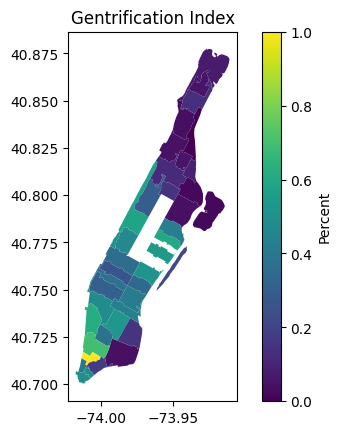

In [38]:
cmap = plt.cm.viridis

df.plot(
    column='gentrification_index',
    cmap=cmap,
    legend=True,
    legend_kwds={'label': "Percent", 'orientation': "vertical"}
)
plt.title("Gentrification Index")
plt.show()